In [1]:
import scanpy as sc 
import pandas as pd 
import numpy as np 

import matplotlib.pyplot as plt 
import seaborn as sns 

from sklearn.metrics import adjusted_rand_score
from sklearn.decomposition import PCA

import scipy.sparse as sp 
import warnings
import torch

warnings.filterwarnings("ignore")

import os
import ctypes
import sys

# 1. 先设置 R_HOME
os.environ["R_HOME"] = "/home/pxy/miniconda3/envs/r40/lib/R"

# 2. 【核心黑科技】手动加载 R 的动态库
# 这步操作等同于在终端里设置 LD_LIBRARY_PATH，专门解决 VS Code 找不到库的问题
try:
    # 这是 R 的核心库路径
    libR_path = "/home/pxy/miniconda3/envs/r40/lib/R/lib/libR.so"
    # 强制加载进内存
    ctypes.CDLL(libR_path, mode=ctypes.RTLD_GLOBAL)
    print("✅ 成功强制加载 libR.so")
except OSError as e:
    print(f"❌ 加载失败: {e}")

# 3. 然后再导入其他包
sys.path.append("..") 

import spCLUE
import rpy2.robjects as robjects
print("R 环境路径:", robjects.r['R.home']()[0])

spCLUE.fix_seed(0)

✅ 成功强制加载 libR.so
R 环境路径: /home/pxy/miniconda3/envs/r40/lib/R


In [2]:
import scanpy as sc
import pandas as pd
import os
import anndata as ad

# 1. 设置路径（替换为你自己的实际路径）
data_dir_slideseq = "/home/pxy/home/pxy/data/Mouse_Olfactory_Bulb_Slide-seqV2/"
print(f"开始加载 Slide-seqV2 数据集...")

# 2. 加载表达矩阵（优先用 h5ad，更稳定）
adata = sc.read_h5ad(os.path.join(data_dir_slideseq, "filtered_feature_bc_matrix.h5ad"))
adata.var_names_make_unique()
print(f"原始 h5ad 数据: {adata.n_obs} 个 spot, {adata.n_vars} 个基因")

# 3. 加载有效 barcode 列表（用于过滤）
used_barcodes = pd.read_csv(
    os.path.join(data_dir_slideseq, "used_barcodes.txt"),
    header=None,
    names=["barcode"]
)
used_barcodes_set = set(used_barcodes["barcode"])
print(f"有效 barcode 数量: {len(used_barcodes_set)}")

# 4. 加载空间坐标信息
spatial = pd.read_csv(
    os.path.join(data_dir_slideseq, "Puck_200127_15_bead_locations.csv"),
    index_col=0  # 第一列是行号，设为索引
)
# 只保留有效 barcode 的空间坐标
spatial = spatial[spatial["barcode"].isin(used_barcodes_set)]
print(f"有效空间坐标数量: {spatial.shape[0]}")

# 5. 对齐 barcode（确保 adata 和 spatial 索引一致）
# 假设 h5ad 的 obs_names 就是 barcode，如果不一致需要调整
if not adata.obs_names.isin(spatial["barcode"]).any():
    print("检测到索引不匹配，将 adata.obs_names 替换为 barcode")
    # 如果 h5ad 里的 obs 索引不是 barcode，需要从表达文件重新构建
    expr = pd.read_csv(
        os.path.join(data_dir_slideseq, "Puck_200127_15.digital_expression.txt"),
        sep="\t",
        index_col=0  # 第一列是 gene，行是 gene，列是 barcode
    ).T  # 转置为 (spot × gene)
    # 过滤有效 barcode
    expr = expr[expr.index.isin(used_barcodes_set)]
    # 重建 adata
    adata = ad.AnnData(expr)
    adata.var_names_make_unique()
    print(f"重建后 adata: {adata.n_obs} 个 spot, {adata.n_vars} 个基因")

# 6. 挂载空间坐标到 adata.obsm["spatial"]
# 确保 spatial 的 barcode 顺序和 adata.obs_names 一致
spatial = spatial.set_index("barcode").loc[adata.obs_names, ["xcoord", "ycoord"]]
adata.obsm["spatial"] = spatial.values
print(f"已挂载空间坐标到 adata.obsm['spatial']")

# 7. 输出验证信息（和示例结构保持一致）
print(f"\n数据集: Slide-seqV2 (Mouse Olfactory Bulb)")
print(f"Spot 总数: {adata.n_obs}")
print(f"基因总数: {adata.n_vars}")
print(f"空间坐标维度: {adata.obsm['spatial'].shape}")

# 检查是否有缺失的空间坐标
print(f"空间坐标空值数量: {pd.DataFrame(adata.obsm['spatial']).isna().sum().sum()}")

开始加载 Slide-seqV2 数据集...
原始 h5ad 数据: 20139 个 spot, 21220 个基因
有效 barcode 数量: 20139
有效空间坐标数量: 20139
已挂载空间坐标到 adata.obsm['spatial']

数据集: Slide-seqV2 (Mouse Olfactory Bulb)
Spot 总数: 20139
基因总数: 21220
空间坐标维度: (20139, 2)
空间坐标空值数量: 0


In [3]:
n_clusters_mobv2 = 11

In [ ]:

sc.pp.filter_genes(adata, min_cells=50)
adata = spCLUE.preprocess(adata)
adata.obsm["X_pca"] = PCA(n_components=200, random_state=0).fit_transform(adata.X)
g_spatia = spCLUE.prepare_graph(adata, "spatial",n_neighbors=12)
g_expr = spCLUE.prepare_graph(adata, "expr", metric="euclidean",n_neighbors=12)
graph_dict = {"spatial": g_spatia, "expr":g_expr}

Preprocessing data ---------------->
正在构建图: spatial, 使用度量: cosine ...
  -> 使用空间坐标 (euclidean)
  -> 计算最近邻 (NearestNeighbors)...
  -> 对称化与归一化...
spatial graph created successfully <----

正在构建图: expr, 使用度量: euclidean ...
  -> 使用 PCA 表达特征
  -> 计算最近邻 (NearestNeighbors)...
  -> 对称化与归一化...
expr graph created successfully <----



In [ ]:
model = spCLUE.spCLUE_TwoStage(
    adata.obsm["X_pca"], 
    graph_dict, 
    n_clusters=n_clusters_mobv2,
    dim_input=200,
    pretrain_epochs=100,   # 预训练200轮
    finetune_epochs=100,   # 训练300轮
    gamma=1.0,             # 重构损失权重
    beta=0.0,              # 聚类损失权重=0 
    kappa=1.5,             # 对比损失权重
    theta=0.2,             # 平滑项损失权重
    dim_hidden=32,
    freeze_encoder=False,   # 冻结预训练编码器
    graph_corr=0.4,
    dropout=0.5,
    gate_bias=0.2,
    residual_weight=0.2
)

In [6]:
pred, embed, gated_weights = model.train()

Stage 1: Pre-training Shared Encoder


Pretrain:  18%|█▊        | 18/100 [00:03<00:09,  8.83it/s]

  Pretrain Epoch 10: Rec Loss = 7.184639
  Pretrain Epoch 20: Rec Loss = 6.976860


Pretrain:  45%|████▌     | 45/100 [00:03<00:01, 31.03it/s]

  Pretrain Epoch 30: Rec Loss = 6.653961
  Pretrain Epoch 40: Rec Loss = 6.550890


...

  Train Epoch 80: Loss = 22.013086,Rec Loss = 7.163183, Contrast Loss = 9.872360,  Cluster Loss = 0.000000, Smooth Loss = 0.206815


Finetune:  90%|█████████ | 90/100 [01:09<00:07,  1.37it/s]

  Train Epoch 90: Loss = 21.998659,Rec Loss = 7.159581, Contrast Loss = 9.865685,  Cluster Loss = 0.000000, Smooth Loss = 0.202765


Finetune: 100%|██████████| 100/100 [01:16<00:00,  1.31it/s]

  Train Epoch 100: Loss = 21.987612,Rec Loss = 7.155790, Contrast Loss = 9.861053,  Cluster Loss = 0.000000, Smooth Loss = 0.201203

  Finetune Epoch 100:
    Total Loss   = 21.9876
    Rec Loss     = 7.1558
    Contrast Loss = 9.8611
    Smooth Loss = 0.2012
    Gate: spatial=0.632±0.106, expr=0.367±0.106

✓ Finetune finished (max epochs reached)
  [Gate Stats] spatial=0.632±0.106, expr=0.367±0.106


In [7]:
# ========== 聚类 ==========
adata.obsm["spCLUE_twostage"] = embed
spCLUE.clustering(adata, n_clusters_mobv2, key="spCLUE_twostage", refinement=True,cluster_methods='mclust')


R[write to console]:                    __           __ 
   ____ ___  _____/ /_  _______/ /_
  / __ `__ \/ ___/ / / / / ___/ __/
 / / / / / / /__/ / /_/ (__  ) /_  
/_/ /_/ /_/\___/_/\__,_/____/\__/   version 6.1.2
Type 'citation("mclust")' for citing this R package in publications.



fitting ...
  |======================================================================| 100%


AnnData object with n_obs × n_vars = 20139 × 21170
    obs: 'n_counts', 'mclust', 'mclust_refined'
    var: 'n_counts', 'mean', 'std'
    uns: 'log1p'
    obsm: 'spatial', 'X_pca', 'spCLUE_twostage'
    layers: 'count'

In [8]:
import matplotlib.pyplot as plt
import scanpy as sc

# # 1. 准备数据
figures_dir = "figures_MOBV2_use_raw"

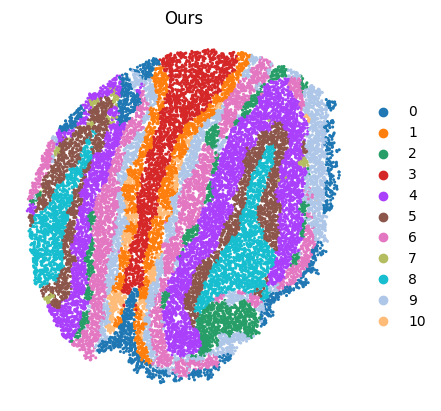

In [9]:
adata.obs["spCLUE"] = adata.obs["mclust_refined"]

# 2. 调用绘图函数 (参考 SpaGIC 的参数)
# 核心修正：添加了 spot_size=40
ax = sc.pl.spatial(
    adata, 
    color=["spCLUE"], 
    spot_size=40,      # 解决 ValueError 的关键
    frameon=False, 
    show=False, 
    title=[f"Ours"]
)

# 3. 参考 SpaGIC 的 y 轴翻转逻辑
# 因为 color 传入的是列表，Scanpy 返回的是 axes 列表，所以需要取 ax[0]
if isinstance(ax, list):
    ax[0].invert_yaxis()
else:
    ax.invert_yaxis()

# 4. 保存与显示
plt.savefig(f"{figures_dir}/MOB_spatial_preprocess_mclust_{n_clusters_mobv2}Clusters_10_8_theta02_gamma10_bias02_graphcorr04.png", bbox_inches='tight', dpi=300)


Detected clusters: 11


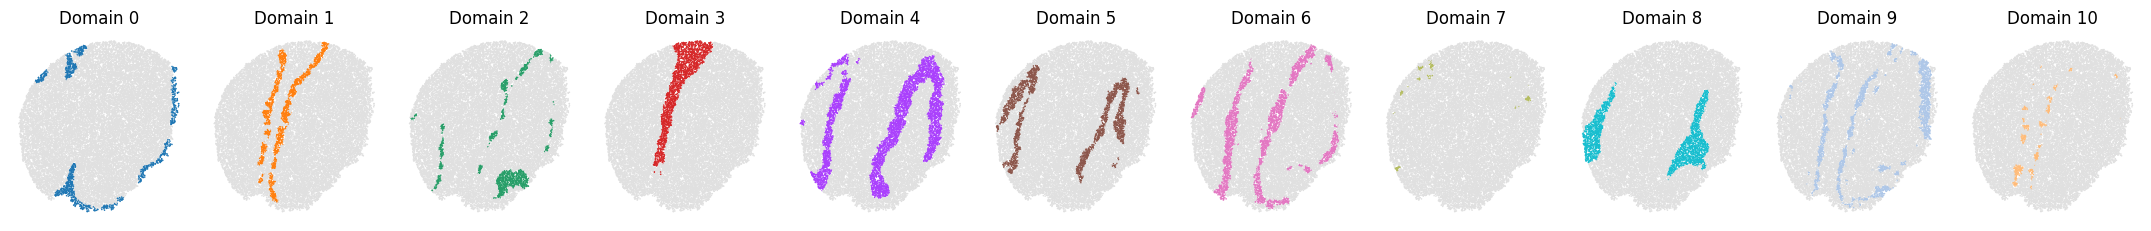

In [10]:
import matplotlib.pyplot as plt
import scanpy as sc
import numpy as np

# 1. 重新获取最新的簇数量，确保不是旧变量
# current_clusters = sorted(adata.obs["spCLUE"].unique())
# 使用 key=int 将字符串转为整数再比较大小
current_clusters = sorted(adata.obs["spCLUE"].unique(), key=lambda x: int(x))
n_cluster = len(current_clusters)
print(f"Detected clusters: {n_cluster}") # 打印确认一下是不是 11 或 12

# 2. 颜色板选择优化
if n_cluster <= 10:
    pl = list(sc.pl.palettes.default_10)
elif n_cluster <= 20:
    pl = list(sc.pl.palettes.default_20)
else:
    # 超过20个簇时使用更广的颜色映射
    pl = sc.pl.palettes.default_102 

# 3. 创建子图布局 - 增加 ncols 的动态确认
# 考虑到 11-12 个簇太宽，建议把 figsize 的每列宽度从 4 缩减到 2.5，避免显示不全
fig, axes = plt.subplots(nrows=1, ncols=n_cluster, figsize=(2.5 * n_cluster, 3.5))

# 如果只有一个簇，axes 不是数组，需要转换
if n_cluster == 1:
    axes = [axes]

for i, cluster in enumerate(current_clusters):
    mask_col = f"temp_{cluster}"
    # 强制转为 category 类型并指定顺序，防止彩色和灰色反掉
    adata.obs[mask_col] = (adata.obs["spCLUE"] == cluster).map({True: 'Target', False: 'Other'}).astype('category')
    
    # 绘图
    sc.pl.spatial(
        adata, 
        color=mask_col, 
        spot_size=40, 
        frameon=False, 
        show=False, 
        # 使用字典映射颜色最保险
        palette={'Other': '#e0e0e0', 'Target': pl[i]}, 
        ax=axes[i], 
        legend_loc=None, 
        title=f"Domain {cluster}",
        library_id=None # 避免寻找不存在的背景图
    )
    
    # 获取正确的 ax 对象
    ax = axes[i]
    ax.invert_yaxis()
    ax.set_xlabel('')
    ax.set_ylabel('')

# 压缩子图间距
plt.subplots_adjust(wspace=0.1)
plt.savefig(f"{figures_dir}/MOB_SingleDomains_Full_{n_cluster}Clusters_10_8_theta02_gamma10_bias02_graphcorr04.png", bbox_inches='tight', dpi=300)
plt.show()